# Notebook 05: Swin-T Two-Stage ABMIL Training
**Goal:** Identical two-stage ABMIL pipeline as NB03/NB04 with Swin-T 
as the backbone. Swin-T is a hierarchical vision transformer producing 
768-dim features. Two deliberate differences from NB03/NB04: learning 
rate lowered to 1e-4 and AdamW used instead of Adam. Both standard 
adjustments for transformer stability.

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"timm    : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
CUDA    : True
timm    : 1.0.26
GPU     : Tesla T4


## 1. Paths and Config
Same NB02 inputs as NB03/NB04. Swin-T-specific changes are in 
hyperparameters only: lower LR (1e-4), AdamW, more epochs (25), 
and more patience (7) to compensate for the smaller step size.

In [2]:
# Paths
NB02 = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
OUT  = Path("/kaggle/working")

X_TRAIN_PATH       = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH       = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH = NB02 / "bag_ids_train.npy"
CLASS_WEIGHTS_PATH = NB02 / "class_weights.json"

S1_WEIGHTS   = OUT / "swin_t_stage1.pth"
S2_WEIGHTS   = OUT / "swin_t_stage2.pth"
RESULTS_JSON = OUT / "swin_t_results.json"

In [3]:
# Hyperparameters
MODEL_NAME = "swin_tiny_patch4_window7_224"
ATTN_DIM   = 128
PATCH_SIZE = 224
SEED       = 42

BS_STAGE1   = 128      # Maintained at 128 for strict structural cross-comparison
LR_STAGE1   = 1e-4     # Lower learning rate for transformer stability
EPOCHS_S1   = 25       # More epochs to compensate for the smaller step size
PATIENCE_S1 = 7        # More patience to give the lower LR timeto work

LR_S2_HEAD  = 1e-4
EPOCHS_S2   = 30
PATIENCE_S2 = 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


In [4]:
import sys
sys.path.append('/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config')
from abmil_common import (
    build_backbone, PatchDataset, PatchClassifier,
    AttentionPool, BagClassifier, CachedBagDataset, collate_cached,
    extract_features, compute_all_metrics, get_normalisation_tensors, run_cv,
)
_mean_gpu, _std_gpu = get_normalisation_tensors(DEVICE)

In [5]:
backbone = build_backbone(MODEL_NAME, pretrained=True).to(DEVICE)

with torch.no_grad():
    _dummy  = torch.zeros(2, 3, PATCH_SIZE, PATCH_SIZE, device=DEVICE)
    _out    = backbone(_dummy)
    FEAT_DIM = _out.shape[1]
    print(f"Backbone output shape : {_out.shape}")
    print(f"FEAT_DIM confirmed    : {FEAT_DIM}")
del _dummy, _out
print("Backbone verified.")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Backbone output shape : torch.Size([2, 768])
FEAT_DIM confirmed    : 768
Backbone verified.


In [6]:
print("Loading arrays...")
X_train_all  = np.load(X_TRAIN_PATH)
y_train_all  = np.load(Y_TRAIN_PATH)
bag_ids_all  = np.load(BAG_IDS_TRAIN_PATH)

fold_ids = np.load(NB02 / "fold_ids.npy")

with open(CLASS_WEIGHTS_PATH) as f:
    raw_cw = json.load(f)
class_weight_dict = {int(k): float(v) for k, v in raw_cw.items()}

print(f"X_train_all : {X_train_all.shape}  dtype={X_train_all.dtype}")
print(f"benign={(y_train_all==0).sum()}  "
      f"malignant={(y_train_all==1).sum()}")
print(f"fold_ids : {fold_ids.shape}  unique folds={sorted(set(fold_ids))}")
print(f"Class weights   : {class_weight_dict}")

Loading arrays...
X_train_all : (58820, 224, 224, 1)  dtype=float32
benign=29225  malignant=29595
fold_ids : (1226,)  unique folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Class weights   : {0: 1.0063301967493585, 1: 0.9937489440783916}


In [7]:
STAGE1_FOLD = 0
all_bags = np.unique(bag_ids_all)
train_bag_indices = all_bags[fold_ids[all_bags] != STAGE1_FOLD]
val_bag_indices   = all_bags[fold_ids[all_bags] == STAGE1_FOLD]

train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_tr    = X_train_all[train_mask];  y_tr  = y_train_all[train_mask]
bag_tr  = bag_ids_all[train_mask]
X_val   = X_train_all[val_mask];    y_val = y_train_all[val_mask]
bag_val = bag_ids_all[val_mask]

print(f"Stage 1 fixed split (fold {STAGE1_FOLD} held out): "
      f"train_bags={len(train_bag_indices)}  val_bags={len(val_bag_indices)}")
print(f"Train patches : {X_tr.shape}  "
      f"benign={(y_tr==0).sum()}  malignant={(y_tr==1).sum()}")
print(f"Val patches   : {X_val.shape}  "
      f"benign={(y_val==0).sum()}  malignant={(y_val==1).sum()}")

Stage 1 fixed split (fold 0 held out): train_bags=985  val_bags=241
Train patches : (47252, 224, 224, 1)  benign=23273  malignant=23979
Val patches   : (11568, 224, 224, 1)  benign=5952  malignant=5616


In [8]:
patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
criterion_s1   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_val, device=DEVICE))

# Upgraded to AdamW to safely process Transformer weight-decay computations
optimiser_s1 = optim.AdamW(patch_model.parameters(), lr=LR_STAGE1, weight_decay=1e-2)
scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(optimiser_s1, mode='min', factor=0.5, patience=3)

train_patch_dl = DataLoader(PatchDataset(X_tr, y_tr), batch_size=BS_STAGE1, shuffle=True, num_workers=2, pin_memory=True)
val_patch_dl   = DataLoader(PatchDataset(X_val, y_val), batch_size=BS_STAGE1, shuffle=False, num_workers=2, pin_memory=True)

In [9]:
# Stage 1 training loop (GPU-accelerated)
scaler = torch.amp.GradScaler('cuda')

s1_history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
best_val_loss_s1    = float("inf")
patience_counter_s1 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S1 + 1):
    patch_model.train()
    running_loss = 0.0
    for patches, labels in train_patch_dl:
        patches, labels = patches.to(DEVICE), labels.to(DEVICE)
        
        # Super-speed batched transformation on GPU tensor cores
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        optimiser_s1.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = patch_model(patches)
            loss = criterion_s1(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimiser_s1)
        scaler.update()
        
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_patch_dl.dataset)

    patch_model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for patches, labels in val_patch_dl:
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            
            patches = patches.repeat(1, 3, 1, 1)
            patches = (patches - _mean_gpu) / _std_gpu
            
            with torch.amp.autocast('cuda'):
                logits   = patch_model(patches)
                loss_val = criterion_s1(logits, labels)
                
            val_loss += loss_val.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss  /= len(val_patch_dl.dataset)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    val_preds  = (all_probs >= 0.5).astype(int)
    val_auc    = roc_auc_score(all_labels, all_probs)
    val_f1     = f1_score(all_labels, val_preds, zero_division=0)

    s1_history["train_loss"].append(train_loss)
    s1_history["val_loss"].append(val_loss)
    s1_history["val_auc"].append(val_auc)
    s1_history["val_f1"].append(val_f1)
    scheduler_s1.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S1}  train={train_loss:.4f}  val={val_loss:.4f}  auc={val_auc:.4f}  f1={val_f1:.4f}")

    if val_loss < best_val_loss_s1:
        best_val_loss_s1    = val_loss
        patience_counter_s1 = 0
        torch.save(patch_model.state_dict(), S1_WEIGHTS)
        print("  ✓ Saved best Stage 1 weights")
    else:
        patience_counter_s1 += 1
        if patience_counter_s1 >= PATIENCE_S1:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 1 complete: {(time.time()-t0)/60:.1f} min")

Ep 01/25  train=0.6498  val=0.7140  auc=0.6156  f1=0.6022
  ✓ Saved best Stage 1 weights
Ep 02/25  train=0.5941  val=0.6154  auc=0.6972  f1=0.6191
  ✓ Saved best Stage 1 weights
Ep 03/25  train=0.5629  val=0.6135  auc=0.7158  f1=0.6260
  ✓ Saved best Stage 1 weights
Ep 04/25  train=0.5188  val=0.6813  auc=0.6956  f1=0.6309
Ep 05/25  train=0.4491  val=0.7302  auc=0.6833  f1=0.6108
Ep 06/25  train=0.3638  val=0.7807  auc=0.6767  f1=0.6062
Ep 07/25  train=0.2895  val=0.9065  auc=0.6889  f1=0.6210
Ep 08/25  train=0.1892  val=1.1315  auc=0.6898  f1=0.6181
Ep 09/25  train=0.1483  val=1.3018  auc=0.6821  f1=0.6044
Ep 10/25  train=0.1248  val=1.4077  auc=0.6763  f1=0.5977
  Early stopping at epoch 10

Stage 1 complete: 56.6 min


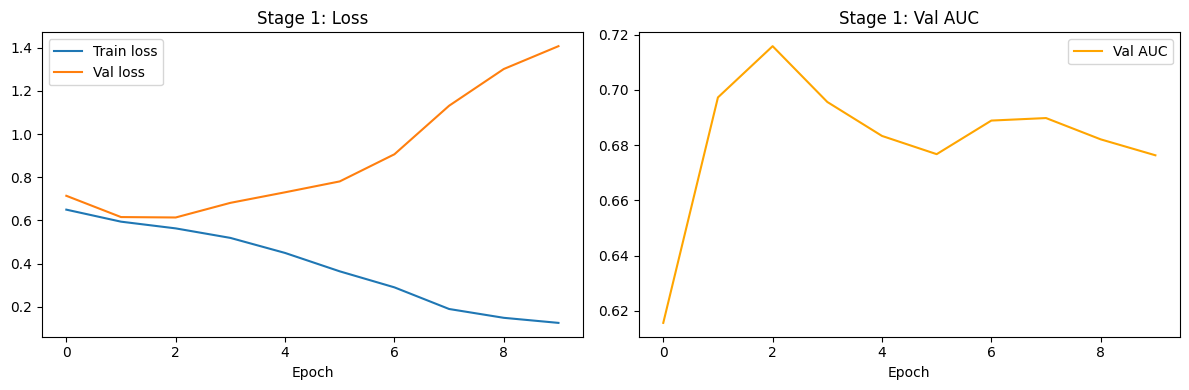

Saved swin_t_stage1_curves.png


In [10]:
# Stage 1 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s1_history["train_loss"], label="Train loss")
axes[0].plot(s1_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 1: Loss");     axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[1].plot(s1_history["val_auc"], color="orange", label="Val AUC")
axes[1].set_title("Stage 1: Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(OUT / "swin_t_stage1_curves.png", dpi=150)
plt.show()
print("Saved swin_t_stage1_curves.png")

In [11]:
# Stage 1 patch-level diagnostic metrics
patch_model.load_state_dict(torch.load(S1_WEIGHTS, map_location=DEVICE))
patch_model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in val_patch_dl:
        patches = patches.to(DEVICE)
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        with torch.amp.autocast('cuda'):
            all_probs.extend(torch.sigmoid(patch_model(patches)).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

s1_metrics = {
    "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
    "patch_f1"         : float(f1_score(all_labels, preds, zero_division=0)),
    "patch_sensitivity": float(recall_score(all_labels, preds, zero_division=0)),
    "patch_specificity": float(tn / (tn + fp)),
}
print("─Stage 1 Patch-Level Val Metrics -")
for k, v in s1_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

─Stage 1 Patch-Level Val Metrics -
  patch_auc                : 0.7158
  patch_f1                 : 0.6260
  patch_sensitivity        : 0.5751
  patch_specificity        : 0.7525


In [12]:
# Feature extraction
feature_extractor = patch_model.backbone
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)

print("Extracting train features...")
feats_tr  = extract_features(X_tr,  feature_extractor, _mean_gpu, _std_gpu, DEVICE)
print(f"  train : {feats_tr.shape}")

print("Extracting val features...")
feats_val = extract_features(X_val, feature_extractor, _mean_gpu, _std_gpu, DEVICE)
print(f"  val   : {feats_val.shape}")

Extracting train features...
  train : (47252, 768)
Extracting val features...
  val   : (11568, 768)


In [13]:
import gc

del X_tr, X_val
gc.collect()
torch.cuda.empty_cache()

print(f"Running 5-fold CV for Stage 2 ({MODEL_NAME})...")
feats_all = extract_features(X_train_all, feature_extractor, _mean_gpu, _std_gpu, DEVICE)

del X_train_all
gc.collect()

Running 5-fold CV for Stage 2 (swin_tiny_patch4_window7_224)...


0

In [14]:
cv_results, cv_summary = run_cv(
    feats_all, y_train_all, bag_ids_all, fold_ids, feat_dim=FEAT_DIM,
    attn_dim=ATTN_DIM, dropout=0.25, gated=True, tag=MODEL_NAME,
    device=DEVICE
)
print(cv_summary)

with open(OUT / f"{MODEL_NAME}_cv_results.json", "w") as f:
    json.dump({
        "model": MODEL_NAME, "feat_dim": FEAT_DIM,
        "fold_results": cv_results,
        "cv_mean": cv_summary.loc["mean"].to_dict(),
        "cv_std": cv_summary.loc["std"].to_dict(),
    }, f, indent=2)
print("Saved:", f"{MODEL_NAME}_cv_results.json")

── [swin_tiny_patch4_window7_224] Fold 0 ──
  threshold      : 0.2330
  auc            : 0.7517
  f1             : 0.6687
  sensitivity    : 0.9231
  specificity    : 0.2097
  fpr            : 0.7903
  mcc            : 0.1883
  ece            : 0.0963
  confusion      : TN=26 FP=98 FN=9 TP=108
── [swin_tiny_patch4_window7_224] Fold 1 ──
  threshold      : 0.3858
  auc            : 0.9291
  f1             : 0.8216
  sensitivity    : 0.9083
  specificity    : 0.7462
  fpr            : 0.2538
  mcc            : 0.6555
  ece            : 0.0680
  confusion      : TN=97 FP=33 FN=10 TP=99
── [swin_tiny_patch4_window7_224] Fold 2 ──
  threshold      : 0.3680
  auc            : 0.9493
  f1             : 0.8889
  sensitivity    : 0.9091
  specificity    : 0.8475
  fpr            : 0.1525
  mcc            : 0.7595
  ece            : 0.0423
  confusion      : TN=100 FP=18 FN=12 TP=120
── [swin_tiny_patch4_window7_224] Fold 3 ──
  threshold      : 0.2795
  auc            : 0.9027
  f1             

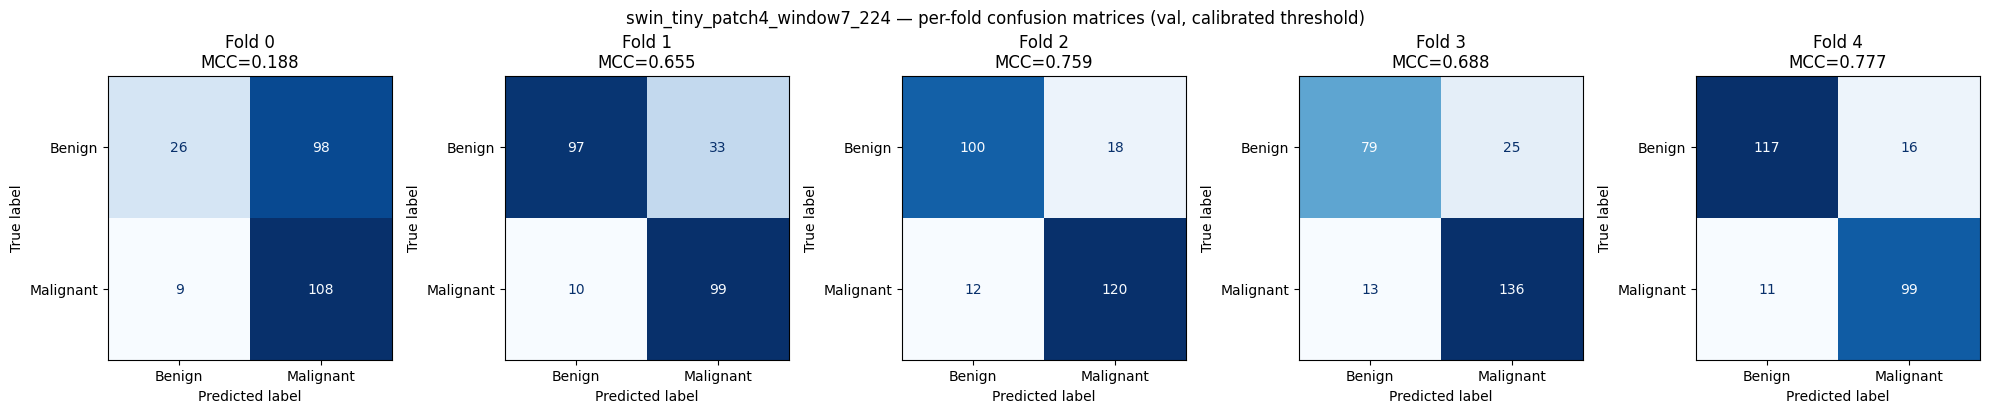

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, r in enumerate(cv_results):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"Fold {i}\nMCC={r['mcc']:.3f}")
plt.suptitle(f"{MODEL_NAME} — per-fold confusion matrices (val, calibrated threshold)")
plt.tight_layout()
plt.savefig(OUT / f"{MODEL_NAME}_confusion_matrices.png", dpi=150)
plt.show()